In [6]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "src"))


In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
from matplotlib import pyplot as plt
import scienceplots

plt.style.use(["science"])

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [9]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from src.probing_dataset import make_sentence_level_probing_dataset, make_word_level_probing_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
from dataclasses import dataclass

@dataclass
class ProbingDataset:
    model_name: str
    hiddens_path: Path
    instruct: bool
    sentence_level_dataset: pd.DataFrame | None = None
    word_level_dataset: pd.DataFrame | None = None

probing_datasets = [
    ProbingDataset(
        model_name="ai-sage/GigaChat3-10B-A1.8B-base",
        instruct=False,
        hiddens_path=Path("../src/results/ai-sage_GigaChat3-10B-A1.8B-base"),
    ),
    # ProbingDataset(
    #     model_name="Qwen/Qwen2.5-7B",
    #     instruct=False,
    #     hiddens_path=Path("../src/results/Qwen_Qwen2.5-7B"),
    # ),
    # ProbingDataset(
    #     model_name="meta-llama/Meta-Llama-3-8B",
    #     instruct=False,
    #     hiddens_path=Path("../src/results/meta-llama_Meta-Llama-3-8B")
    # )
]

for probing_dataset in tqdm(probing_datasets, desc="Load probing dataset"):
    probing_dataset.sentence_level_dataset = make_sentence_level_probing_dataset(
        model_name=probing_dataset.model_name,
        instruct=probing_dataset.instruct,
        model_hiddens_path=probing_dataset.hiddens_path,
        stimuli_csv_path=Path("../hf_datasets/stimuli.csv")
    )
    probing_dataset.word_level_dataset = make_word_level_probing_dataset(
        model_name=probing_dataset.model_name,
        instruct=probing_dataset.instruct,
        model_hiddens_path=probing_dataset.hiddens_path,
        stimuli_csv_path=Path("../hf_datasets/stimuli.csv")
    )

probing_datasets_dict = {probing_dataset.model_name: probing_dataset for probing_dataset in probing_datasets}

Load probing dataset:   0%|          | 0/1 [00:00<?, ?it/s]2025-12-18 16:16:09 INFO     src.tokenizer_utils: Tokenizer adds prefix space
2025-12-18 16:16:10 INFO     src.tokenizer_utils: Tokenizer adds prefix space
Load probing dataset: 100%|██████████| 1/1 [00:03<00:00,  3.36s/it]


## Код для обучения проб

In [11]:
def probe_layers(df, target_labels=["all"], random_state=42):
    df = df.copy()

    if target_labels != ["all"]:
        df = df[df["target"].isin(target_labels)]

    le = LabelEncoder()
    df["target_enc"] = le.fit_transform(df["target"])

    results = []
    per_layer_reports = []
    confusion_matrices = []
    best_acc = 0
    best_layer = None
    best_report = None
    best_conf = None

    cv = StratifiedGroupKFold(
        n_splits=5, shuffle=True, random_state=random_state
    )

    all_layer_accs = {}

    for layer in sorted(df["layer"].unique()):
        sub = df[df["layer"] == layer].reset_index(drop=True)

        X = np.stack(sub["hidden_state"].values)
        y = sub["target_enc"].values
        groups = sub["sentence_id"].values

        layer_accs = []

        for train_idx, test_idx in cv.split(X, y, groups):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            clf = LogisticRegression(
                max_iter=500,
                n_jobs=-1,
                solver="lbfgs",
                multi_class="multinomial" if target_labels == ["all"] or len(target_labels) > 2 else "deprecated",
                random_state=random_state
            )
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            layer_accs.append(accuracy_score(y_test, y_pred))

        all_layer_accs[layer] = layer_accs

        acc = np.mean(layer_accs)
        results.append({"layer": int(layer), "accuracy": acc})

        report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
        per_layer_reports.append(report)

        conf_matrix = confusion_matrix(y_test, y_pred)
        confusion_matrices.append(conf_matrix)

        if acc > best_acc:
            best_acc = acc
            best_layer = layer
            best_report = report
            best_conf = conf_matrix

    return (
        pd.DataFrame(results),
        per_layer_reports,
        confusion_matrices,
        best_layer,
        best_report,
        best_conf,
        all_layer_accs
    )

### Визуализация

In [12]:
def plot_min_max_corridor(all_layer_accs, color: str = "blue"):
    layers = sorted(all_layer_accs.keys())[1:]

    means = np.array([np.mean(all_layer_accs[l]) for l in layers])
    mins  = np.array([np.min(all_layer_accs[l]) for l in layers])
    maxs  = np.array([np.max(all_layer_accs[l]) for l in layers])

    plt.figure(figsize=(5, 2))

    plt.plot(layers, means, color=color)

    plt.fill_between(
        layers,
        mins,
        maxs,
        alpha=0.2,
        color=color
    )

    plt.xlabel("Layer")
    plt.xticks(ticks=[i + 1 for i in range(len(layers))])
    plt.ylabel("Accuracy")
    plt.ylim((0.2, 1))
    plt.grid(True)
    plt.legend()
    plt.show()

In [13]:
def plot_confusion_matrix(cm: np.ndarray, class_names: list[str], title: str = "Confusion Matrix"):

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(cm, interpolation='nearest', cmap="viridis")

    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Count", rotation=-90, va="bottom")

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=title
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="black" if cm[i, j] > thresh else "white",
                fontsize=12,
            )

    plt.grid(False)
    plt.tight_layout()
    plt.show()

### Sentence-level tokens probing

На какие вопросы пытаемся ответить:

- Кодирует ли LLM тип ошибки в глобальном представлении предложения.
- Отделимы ли типы ошибок линейным классификатором

Normal vs Grammar-incongruent

Normal vs Semantic-incongruent

Grammar-incongruent vs Grammar/Semantic-incongruent

### Word-level probing

In [14]:
probing_datasets_dict.keys()

dict_keys(['ai-sage/GigaChat3-10B-A1.8B-base'])

In [15]:
probing_results = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting"):
    probing_results[k] = probe_layers(df=v.word_level_dataset)

Probe fitting:   0%|          | 0/1 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PAR

Gigachat

In [16]:
(gc_wl_results,
 gc_wl_per_layer_reports,
 gc_wl_confusion_matrices,
 gc_wl_best_layer,
 gc_wl_best_report,
 gc_wl_best_conf,
 gc_wl_all_layer_accs) = probing_results["ai-sage/GigaChat3-10B-A1.8B-base"]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


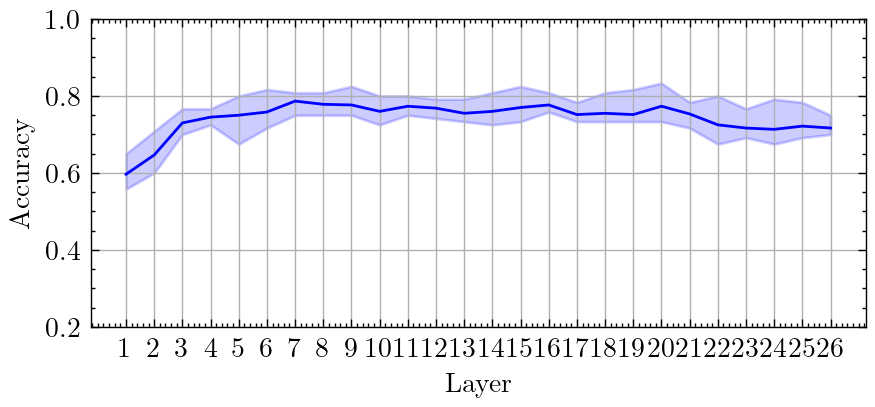

In [17]:
plot_min_max_corridor(gc_wl_all_layer_accs)

In [18]:
gc_wl_best_conf

array([[19, 10,  0,  1],
       [ 0, 28,  2,  0],
       [ 0,  0, 27,  3],
       [ 0,  0, 11, 19]])

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

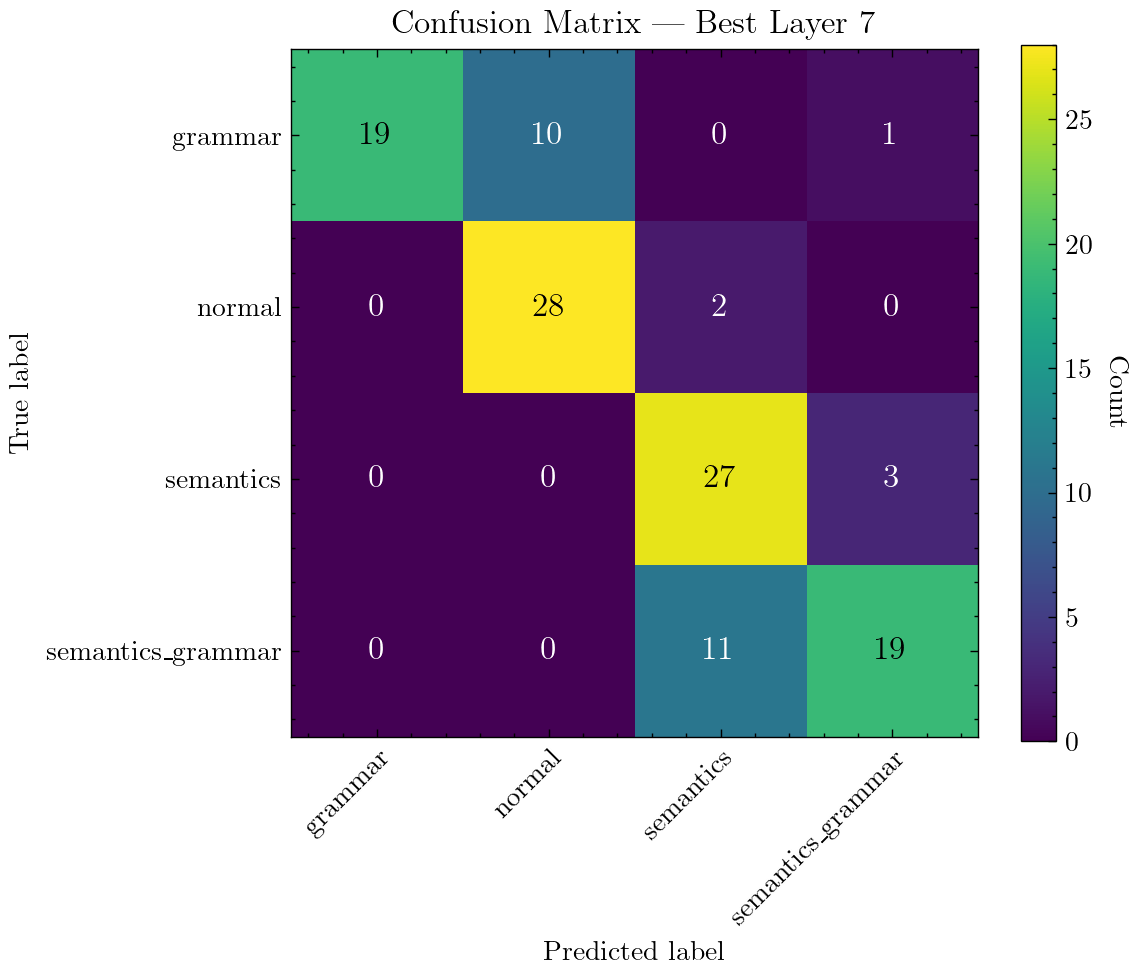

In [19]:
plot_confusion_matrix(
    gc_wl_best_conf,
    class_names=list(gc_wl_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {gc_wl_best_layer}"
)

rQwen2.5-7B

In [20]:
(qw_wl_results,
 qw_wl_per_layer_reports,
 qw_wl_confusion_matrices,
 qw_wl_best_layer,
 qw_wl_best_report,
 qw_wl_best_conf,
 qw_wl_all_layer_accs) = probing_results["Qwen/Qwen2.5-7B"]

KeyError: 'Qwen/Qwen2.5-7B'

In [ ]:
plot_confusion_matrix(
    qw_wl_best_conf,
    class_names=list(gc_wl_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {gc_wl_best_layer} (Qwen2.5-7B)"
)

In [ ]:
plot_min_max_corridor(qw_wl_all_layer_accs, color = "orange")

## Normal vs Grammar-incongruent

Probe fitting norm vs gramm: 100%|██████████| 1/1 [02:29<00:00, 149.73s/it]


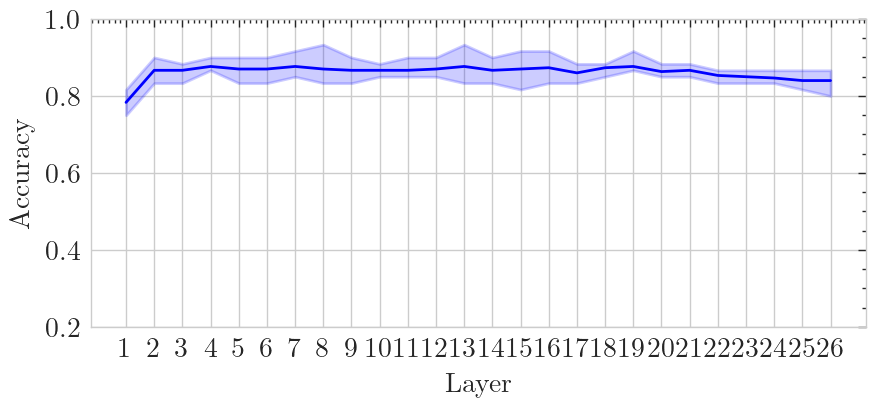

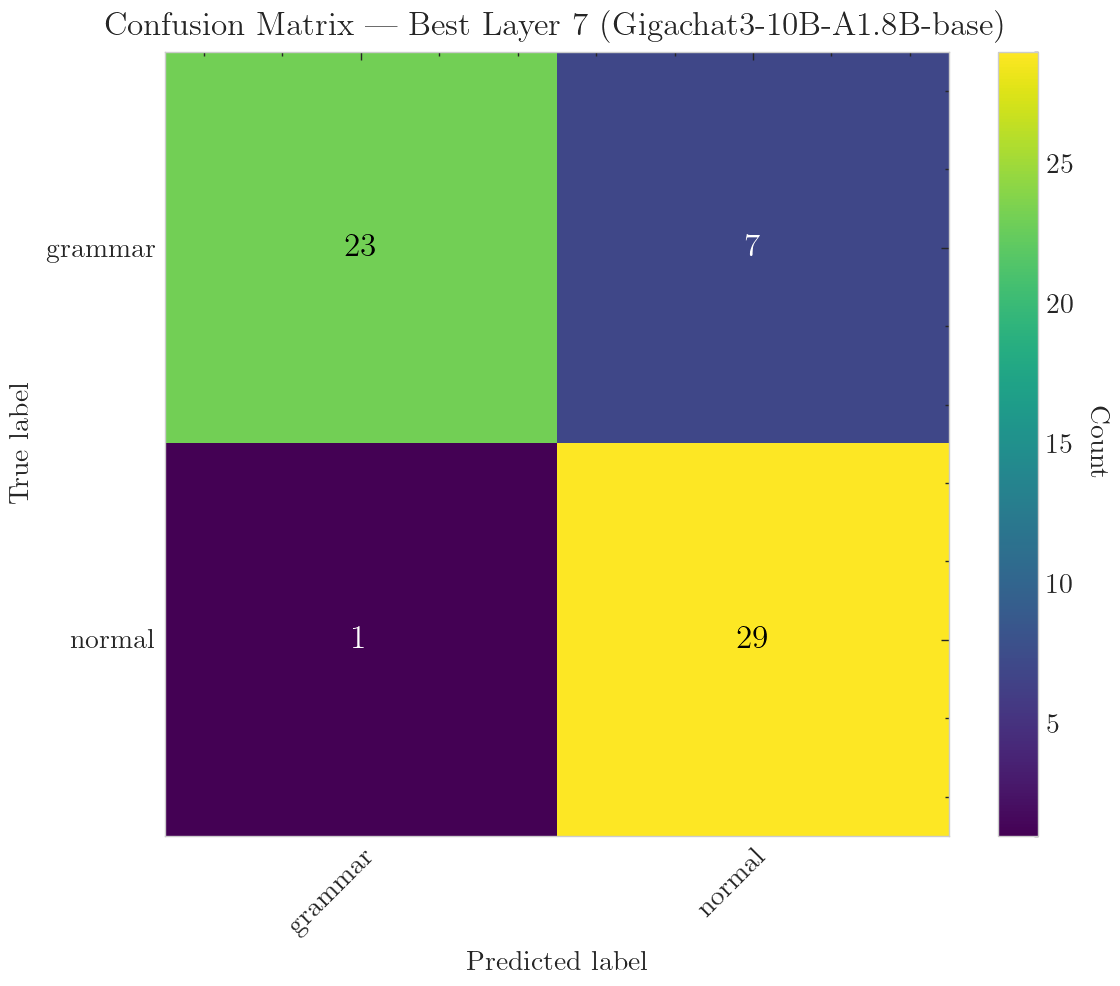

In [23]:
norm_vs_gramm_probing_results = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting norm vs gramm"):
    norm_vs_gramm_probing_results[k] = probe_layers(df=v.word_level_dataset, target_labels=["normal", "grammar"])

(gc_ng_wl_results,
 gc_ng_per_layer_reports,
 gc_ng_confusion_matrices,
 gc_ng_best_layer,
 gc_ng_best_report,
 gc_ng_best_conf,
 gc_ng_all_layer_accs) = norm_vs_gramm_probing_results["ai-sage/GigaChat3-10B-A1.8B-base"]

plot_min_max_corridor(gc_ng_all_layer_accs)
plot_confusion_matrix(
    gc_ng_best_conf,
    class_names=list(gc_ng_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {gc_wl_best_layer} (Gigachat3-10B-A1.8B-base)"
)

In [ ]:
norm_vs_semantics_probing_results = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting norm vs gramm"):
    norm_vs_semantics_probing_results[k] = probe_layers(df=v.word_level_dataset, target_labels=["normal", "semantics"])

(gc_ns_wl_results,
 gc_ns_per_layer_reports,
 gc_ns_confusion_matrices,
 gc_ns_best_layer,
 gc_ng_best_report,
 gc_ng_best_conf,
 gc_ng_all_layer_accs) = norm_vs_gramm_probing_results["ai-sage/GigaChat3-10B-A1.8B-base"]

plot_min_max_corridor(gc_ng_all_layer_accs)
plot_confusion_matrix(
    gc_ng_best_conf,
    class_names=list(gc_ng_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {gc_wl_best_layer} (Gigachat3-10B-A1.8B-base)"
)

Qwen

In [ ]:
(qw_ng__wl_results,
 qw_ng__wl_per_layer_reports,
 qw_ng__wl_confusion_matrices,
 qw_ng__wl_best_layer,
 qw_ng__wl_best_report,
 qw_ng__wl_best_conf,
 qw_ng__wl_all_layer_accs) = norm_vs_gramm_probing_results["Qwen/Qwen2.5-7B"]

plot_min_max_corridor(qw_ng__wl_all_layer_accs, color = "orange")
plot_confusion_matrix(
    qw_ng__wl_best_conf,
    class_names=list(qw_ng__wl_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {qw_ng__wl_best_layer} (Qwen2.5-7B)"
)

### Grammar vs Semantic-Grammar incongruent

In [21]:
norm_vs_gramm_probing_results

{'ai-sage/GigaChat3-10B-A1.8B-base': (    layer  accuracy
  0       0  0.793333
  1       1  0.783333
  2       2  0.866667
  3       3  0.866667
  4       4  0.876667
  5       5  0.870000
  6       6  0.870000
  7       7  0.876667
  8       8  0.870000
  9       9  0.866667
  10     10  0.866667
  11     11  0.866667
  12     12  0.870000
  13     13  0.876667
  14     14  0.866667
  15     15  0.870000
  16     16  0.873333
  17     17  0.860000
  18     18  0.873333
  19     19  0.876667
  20     20  0.863333
  21     21  0.866667
  22     22  0.853333
  23     23  0.850000
  24     24  0.846667
  25     25  0.840000
  26     26  0.840000,
  [{'grammar': {'precision': 0.78125,
     'recall': 0.8333333333333334,
     'f1-score': 0.8064516129032258,
     'support': 30.0},
    'normal': {'precision': 0.8214285714285714,
     'recall': 0.7666666666666667,
     'f1-score': 0.7931034482758621,
     'support': 30.0},
    'accuracy': 0.8,
    'macro avg': {'precision': 0.8013392857142857,

In [22]:
grammar_vs_semantics_grammar_probing_results = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting grammar vs semantics grammar"):
    grammar_vs_semantics_grammar_probing_results[k] = probe_layers(df=v.word_level_dataset, target_labels=["grammar", "semantics_grammar"])

Probe fitting grammar vs semantics grammar: 100%|██████████| 1/1 [02:25<00:00, 145.71s/it]


In [ ]:
grammar_vs_semantics_grammar_probing_results

In [ ]:
# model_name = "ai-sage/GigaChat3-10B-A1.8B-base"
model_name = "Qwen/Qwen2.5-7B"

(gc_gsg_wl_results,
 gc_gsg_per_layer_reports,
 gc_gsg_confusion_matrices,
 gc_gsg_best_layer,
 gc_gsg_best_report,
 gc_gsg_best_conf,
 gc_gsg_all_layer_accs) = norm_vs_gramm_probing_results[model_name]

plot_min_max_corridor(gc_gsg_all_layer_accs, color = "orange")
plot_confusion_matrix(
    gc_gsg_best_conf,
    class_names=list(gc_gsg_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {gc_gsg_best_layer} ({model_name.split('/')[1]})"
)

Probe fitting norm vs gramm:   0%|          | 0/1 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable 

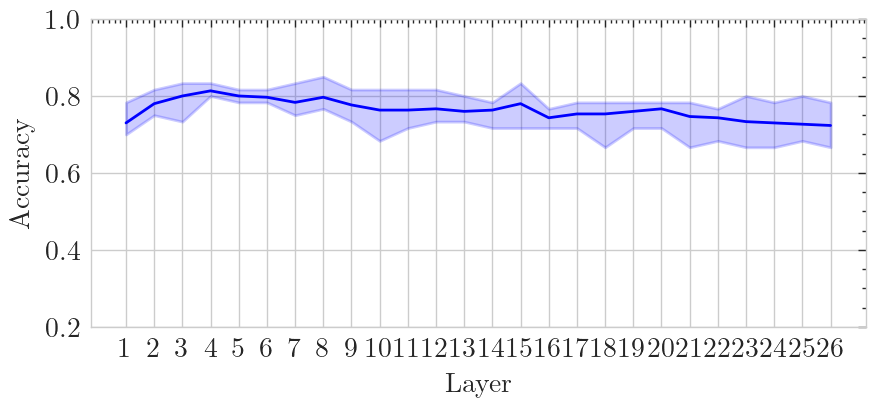

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

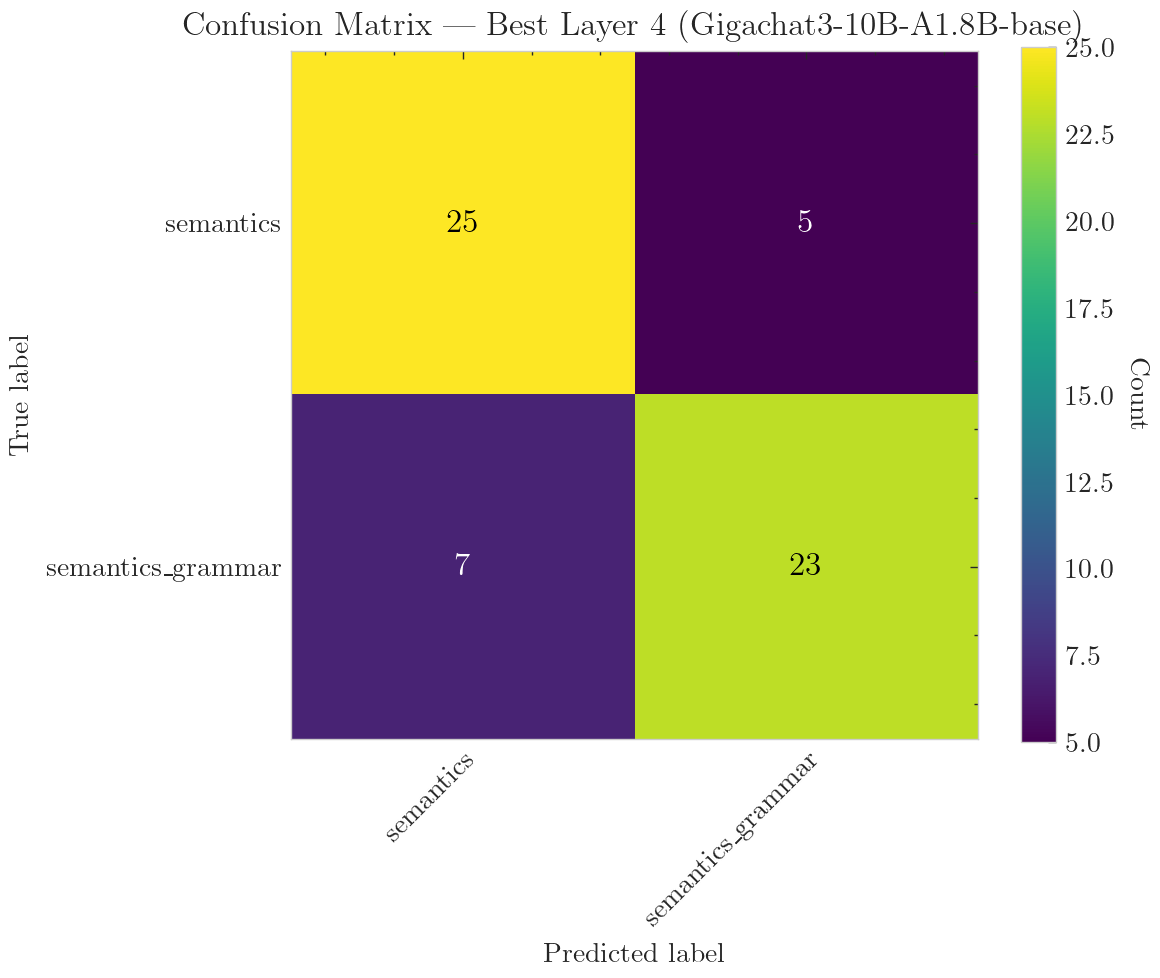

In [25]:
semantics_vs_semantics_and_gramatic_probing_results = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting norm vs gramm"):
    semantics_vs_semantics_and_gramatic_probing_results[k] = probe_layers(df=v.word_level_dataset, target_labels=["semantics", "semantics_grammar"])

(gc_ssg_wl_results,
 gc_ssg_per_layer_reports,
 gc_ssg_confusion_matrices,
 gc_ssg_best_layer,
 gc_ssg_best_report,
 gc_ssg_best_conf,
 gc_ssg_all_layer_accs) = semantics_vs_semantics_and_gramatic_probing_results["ai-sage/GigaChat3-10B-A1.8B-base"]

plot_min_max_corridor(gc_ssg_all_layer_accs)
plot_confusion_matrix(
    gc_ssg_best_conf,
    class_names=list(gc_ssg_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {gc_ssg_best_layer} (Gigachat3-10B-A1.8B-base)"
)